In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[ 8.43721863,  6.44479158],
       [ 6.29040733,  4.91841317],
       [ 0.18430994,  7.85106243],
       ...,
       [ 9.1980819 , -5.40636308],
       [ 8.846045  , -6.33100332],
       [-1.24244954,  9.02219052]], shape=(1000, 2))

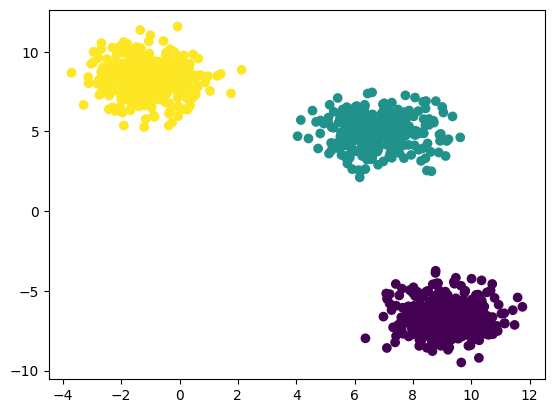

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
## standardization - feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [9]:
## train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [10]:
X_train_scaled=scaler.fit_transform(X_train)

In [11]:
X_test_scaled=scaler.transform(X_test)

In [12]:
from sklearn.cluster import KMeans

In [13]:
## Elbow Method to select the K value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [14]:
wcss

[1340.0000000000007,
 444.37805872316926,
 47.65827722683456,
 40.852366996508444,
 33.63359957664249,
 26.614522943492865,
 24.34265684181013,
 22.364139833350137,
 21.319622019921542,
 18.590906452503226]

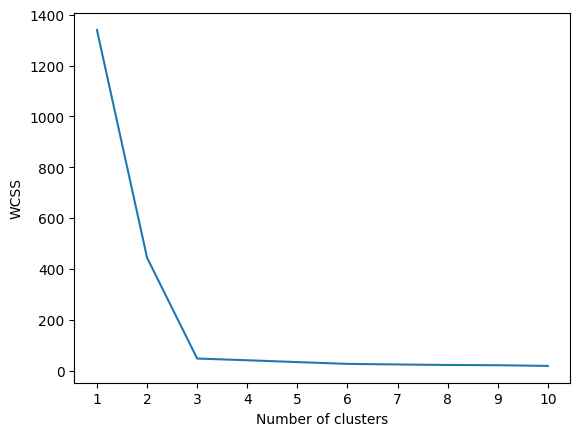

In [15]:
## plot the elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [17]:
kmeans.fit_predict(X_train_scaled)

array([2, 1, 1, 1, 1, 0, 1, 2, 2, 2, 0, 1, 1, 2, 2, 0, 2, 2, 0, 1, 0, 0,
       1, 2, 2, 2, 1, 0, 2, 0, 2, 2, 0, 1, 1, 1, 1, 2, 0, 0, 2, 0, 2, 1,
       2, 2, 1, 0, 1, 2, 0, 1, 2, 1, 1, 0, 0, 0, 1, 1, 0, 2, 0, 2, 2, 1,
       2, 1, 1, 2, 1, 0, 1, 2, 1, 1, 0, 2, 2, 1, 1, 0, 1, 1, 0, 1, 2, 2,
       2, 2, 0, 1, 1, 1, 2, 1, 0, 2, 0, 2, 2, 2, 1, 2, 1, 2, 0, 1, 1, 2,
       0, 2, 2, 0, 2, 1, 2, 0, 0, 0, 0, 2, 1, 1, 2, 0, 0, 1, 0, 0, 1, 1,
       1, 2, 2, 2, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 0, 0, 2, 1, 2, 2,
       1, 1, 0, 1, 1, 0, 2, 1, 1, 1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 0, 2, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 2, 1, 2, 1, 1, 0, 2, 2,
       0, 0, 2, 0, 1, 0, 2, 2, 1, 2, 1, 0, 2, 2, 0, 2, 2, 0, 2, 1, 1, 1,
       0, 0, 2, 0, 1, 1, 1, 2, 2, 1, 1, 0, 0, 0, 2, 2, 0, 2, 0, 1, 2, 0,
       0, 1, 1, 0, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 1, 2, 0, 0, 2, 0, 2, 0,
       0, 0, 2, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 1, 1,
       1, 2, 0, 1, 0, 0, 0, 0, 1, 2, 2, 0, 0, 1, 2,

In [18]:
y_pred=kmeans.predict(X_test_scaled)

In [19]:
y_pred

array([0, 2, 1, 2, 0, 2, 0, 0, 1, 0, 1, 1, 2, 1, 0, 1, 2, 1, 0, 0, 2, 1,
       0, 2, 0, 2, 0, 2, 0, 1, 1, 1, 0, 2, 0, 1, 2, 1, 2, 1, 2, 2, 1, 0,
       2, 2, 2, 2, 1, 0, 0, 2, 1, 2, 0, 1, 1, 1, 2, 0, 0, 0, 2, 2, 2, 2,
       1, 0, 2, 2, 1, 2, 2, 2, 2, 2, 0, 0, 1, 1, 1, 1, 0, 2, 0, 2, 2, 1,
       1, 0, 0, 1, 2, 2, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 2, 1, 0, 1, 0,
       0, 0, 1, 1, 2, 2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2, 0,
       2, 2, 1, 2, 0, 0, 1, 2, 0, 1, 2, 0, 2, 2, 2, 2, 0, 0, 2, 1, 2, 1,
       2, 2, 1, 2, 0, 0, 1, 2, 0, 2, 0, 0, 2, 1, 1, 0, 1, 2, 2, 0, 0, 1,
       1, 1, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0, 0, 0, 2, 0,
       0, 2, 2, 1, 2, 1, 2, 0, 0, 2, 1, 0, 2, 2, 2, 0, 1, 2, 2, 0, 2, 1,
       0, 2, 0, 1, 1, 0, 0, 1, 0, 2, 1, 1, 1, 1, 2, 0, 2, 1, 2, 2, 1, 0,
       2, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 1, 2, 1, 0, 0, 0, 0, 0,
       0, 0, 2, 1, 0, 2, 0, 2, 1, 1, 0, 1, 1, 2, 1, 1, 1, 0, 2, 1, 1, 2,
       0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 2, 0, 1, 2, 2,

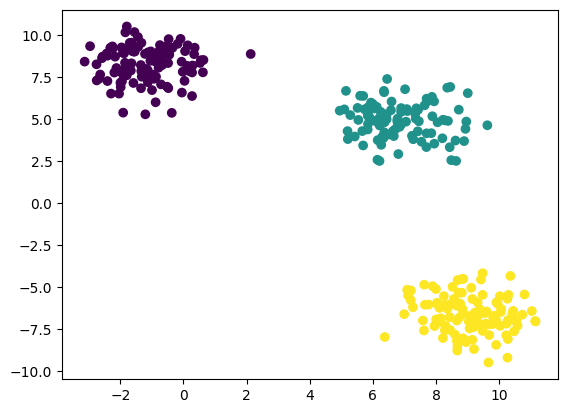

In [23]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [25]:
## Validating the k value
## 1. kneelocator
## 2. Silhoutee scoring

In [26]:
## kneelocator
!pip install kneed

  Obtaining dependency information for kneed from https://files.pythonhosted.org/packages/4a/cd/23c89d53c36028bccb39f55aa5dd24c4bdaab76c4d556ad43dc8cf026918/kneed-0.8.6-py3-none-any.whl.metadata


In [27]:
from kneed import KneeLocator

In [28]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [29]:
kl.elbow

np.int64(3)

In [30]:
## Siloutee scoring
from sklearn.metrics import silhouette_score

In [32]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [33]:
silhouette_coefficients

[0.6527136602165595,
 0.8152795494714934,
 0.6860690184299837,
 0.6576666157416862,
 0.3863011437702972,
 0.37488886797415066,
 0.3673879129029331,
 0.3737437625498684,
 0.3417479531692005]

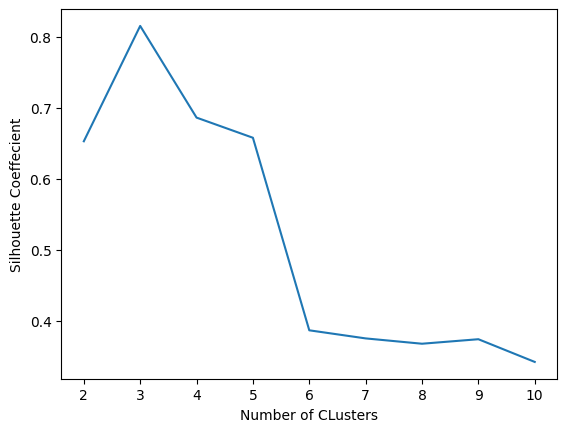

In [34]:
## Plot Silhouette Score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of CLusters")
plt.ylabel("Silhouette Coeffecient")
plt.show()